# Finding the P5 oscillator from the SCCs of the cycling subnetwork

`00_1_cyclical_attractor_analysis.ipynb` lists every feedback loop inside the P5 attractors and
groups the loops by hand into an AMPK (`PRKA`)–ULK1–MTOR oscillator, a mitophagy loop and an
autophagy/apoptosis crosstalk. This notebook asks whether a single structural step on the network
**of the nodes that actually cycle in P5** finds that oscillator directly.

That step is the **strongly connected component** (SCC): a maximal set of nodes in which every node
can reach every other. Every feedback loop lies entirely inside one SCC, and nodes outside SCCs
only relay signals. By Thomas' rule, a sustained oscillation needs a **negative** loop.

Steps:

1. Compute the four P5 attractors.
2. Keep only the nodes that cycle, that is, take both values inside the attractor.
3. Build the subnetwork of those nodes from the signed interaction graph.
4. Decompose it into SCCs.
5. Identify the oscillator: the SCC whose loops are all negative, and that nothing else regulates.

In [1]:
import os
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import biobalm
import biodivine_aeon as ba
import networkx as nx
import pandas as pd
import pygraphviz as pgv
from IPython.display import Image

if not Path("model").exists():          # repo root, as in 00_1_cyclical_attractor_analysis.ipynb
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)

BNET_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet")
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis"]

## 1 — The P5 attractors

As in `00_1`, P5 = the minimal trap spaces in which all three readouts are free. `biobalm` gives
one seed state per attractor. The attractor is the set of states reachable from that seed
under asynchronous updating, and AEON computes that set symbolically.

In [2]:
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
sd.build()
names = sd.network.variable_names()

p5 = [n for n in sd.minimal_trap_spaces()
      if not any(r in sd.node_data(n)["space"] for r in READOUTS)]
assert len(p5) == 4

graph = ba.AsynchronousGraph(sd.network)
attractors = {f"P5.{k + 1}": ba.Reachability.reach_fwd(
                  graph, graph.mk_subspace(sd.node_attractor_seeds(n, compute=True)[0]))
              for k, n in enumerate(p5)}
spaces = {f"P5.{k + 1}": sd.node_data(n)["space"] for k, n in enumerate(p5)}

pd.DataFrame({k: {"TNF_R_or_DR": spaces[k]["TNF_R_or_DR"], "Insuline": spaces[k]["Insuline"],
                  "attractor states": f"{att.cardinality():.1e}"} for k, att in attractors.items()}).T

,TNF_R_or_DR,Insuline,attractor states
P5.1,1,0,1.3e+14
P5.2,1,1,2.6e+14
P5.3,0,0,2.0e+15
P5.4,0,1,4.1e+15


## 2 — Keep only the cycling nodes

A node **cycles** if the attractor contains states with the node OFF and states with it ON.
Every other node is fixed inside the attractor and acts as a constant.

In [3]:
def cycling_nodes(att):
    return [v for v in names
            if not att.intersect(graph.mk_subspace({v: 0})).is_empty()
            and not att.intersect(graph.mk_subspace({v: 1})).is_empty()]

cycling = {k: cycling_nodes(att) for k, att in attractors.items()}

# Each cycling set equals the free nodes of the minimal trap space
assert all(set(cycling[k]) == set(names) - set(spaces[k]) for k in cycling)
pd.Series({k: len(v) for k, v in cycling.items()}, name="cycling nodes").to_frame().T

,P5.1,P5.2,P5.3,P5.4
cycling nodes,47,48,51,52


In every attractor, the cycling nodes are exactly the free nodes of its trap space: no free node
stays stuck inside the attractor.

## 3 — The cycling subnetwork

Take the signed interaction graph of the full model: one edge per regulation, with sign `+`
(activation) or `-` (inhibition) inferred from the rules. Keep only the cycling nodes and the edges
between them, and drop all fixed nodes with their edges.

In [4]:
def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

full = signed_graph(ba.BooleanNetwork.from_file(str(BNET_PATH)).infer_valid_graph())
sub = {k: full.subgraph(v).copy() for k, v in cycling.items()}

pd.DataFrame({k: {"nodes": g.number_of_nodes(), "edges": g.number_of_edges()}
              for k, g in [("full model", full)] + list(sub.items())}).T

,nodes,edges
full model,125,216
P5.1,47,66
P5.2,48,67
P5.3,51,70
P5.4,52,71


An edge between two cycling nodes may still have no effect when a fixed node switches its
regulator off. For example, `B = A & C` with `C` fixed at 0. To check this, fix the trap space
values in the rules and let AEON drop the edges that no longer have any effect. The edge sets
match exactly, so every edge kept above is functional inside the attractor.

In [5]:
def percolated_graph(space):
    bn = ba.BooleanNetwork.from_file(str(BNET_PATH))
    for name, value in space.items():
        bn.set_update_function(name, "true" if value else "false")
    return signed_graph(bn.inline_constants(infer_constants=True, repair_graph=True))

assert all(set(sub[k].edges) == set(percolated_graph(spaces[k]).edges) for k in sub)

### The cycling nodes in the whole model

The whole interaction graph, drawn twice: once with the node positions saved in the GINsim file
(`.zginml`), once with a hierarchical (graphviz `dot`) layout. Colour code:

* **dark purple**: cycling in all four P5 attractors (49 nodes);
* **light purple**: cycling in only some of them (TNF- or insulin-dependent);
* **faded**: fixed in every P5 attractor.

An edge is coloured (green = activation, red = inhibition) when both of its ends cycle, and faded
otherwise.

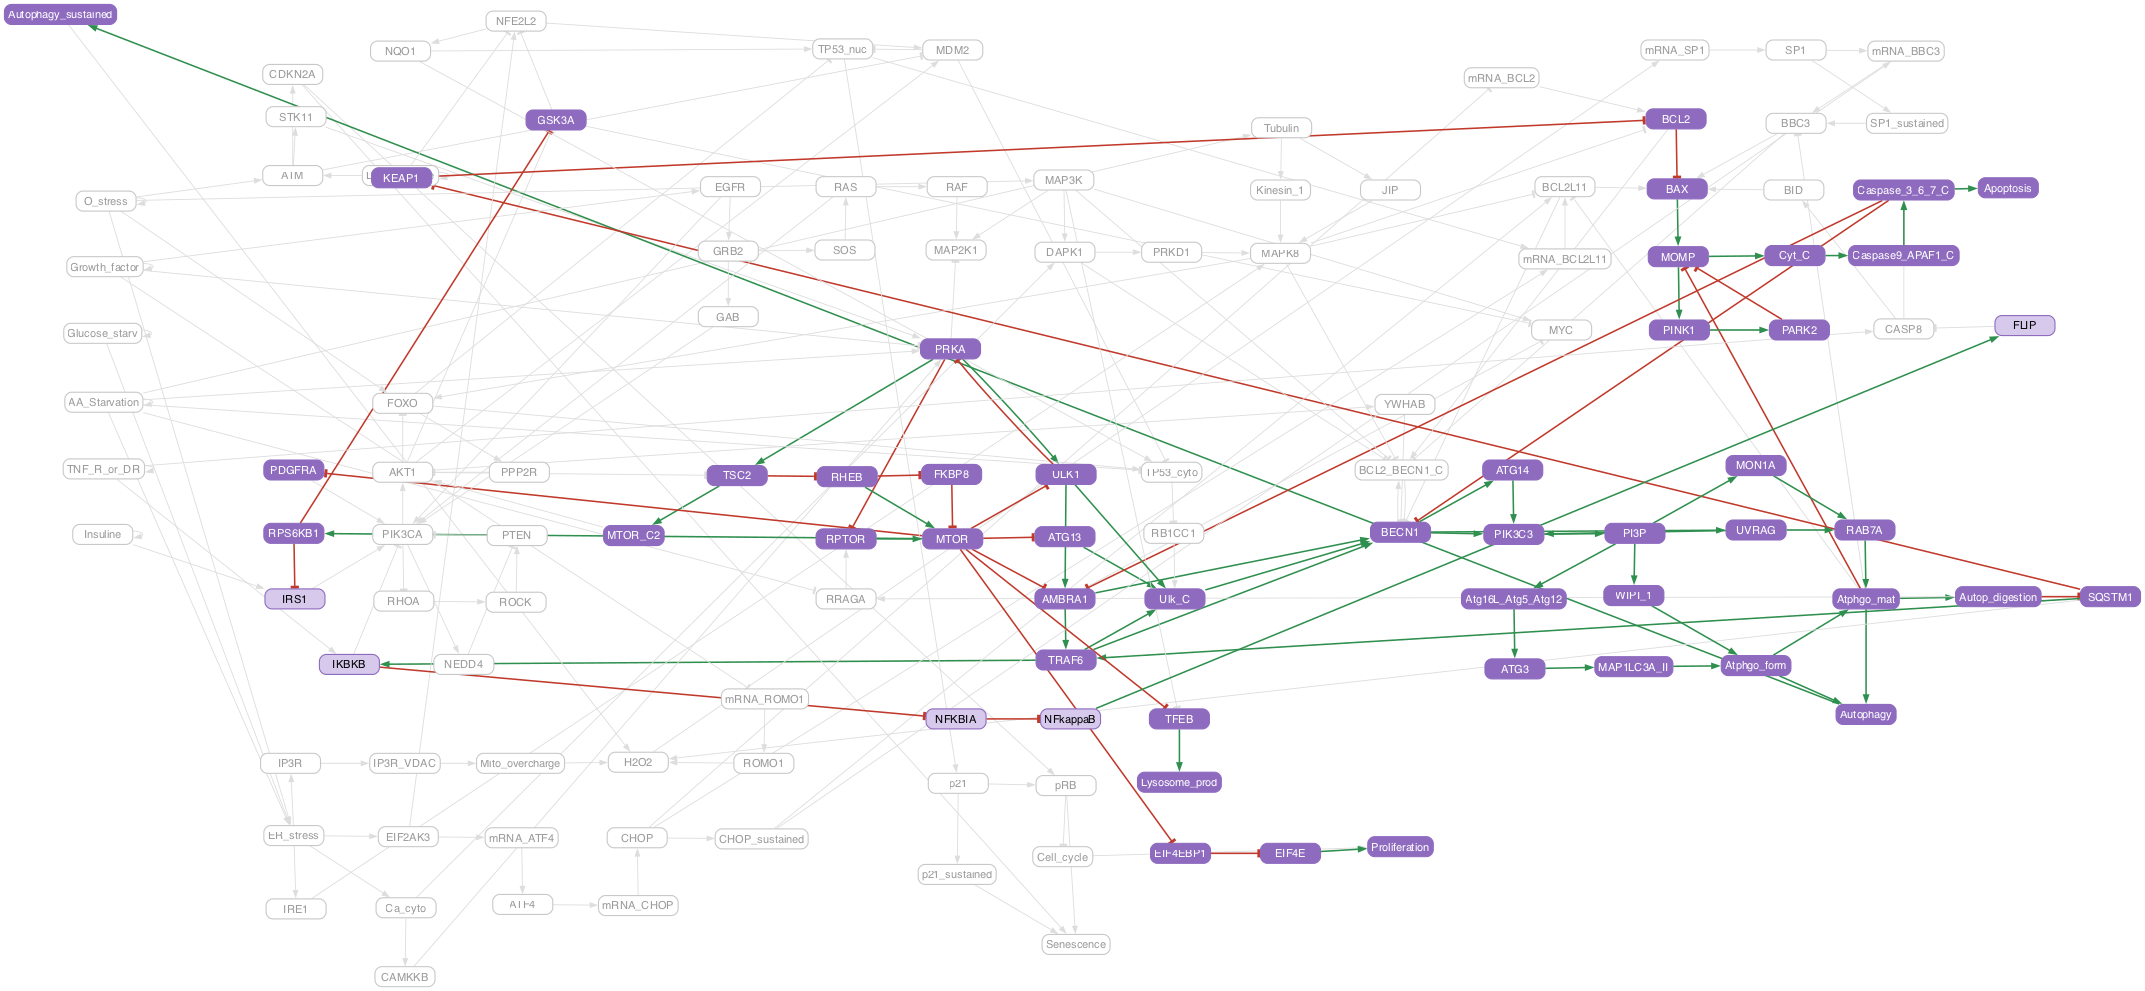

In [7]:
ZGINML_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")

with zipfile.ZipFile(ZGINML_PATH) as z:
    root = ET.fromstring(z.read("GINsim-data/regulatoryGraph.ginml"))
ginsim_pos = {n.get("id"): (float(v.get("x")), float(v.get("y")))
              for n in root.iter("node") for v in n.iter("nodevisualsetting")}
assert set(ginsim_pos) == set(full)

cycling_all = set.intersection(*map(set, cycling.values()))
cycling_any = set.union(*map(set, cycling.values()))
NODE_STYLE = {"all": dict(fillcolor="#8e6bbf", color="#8e6bbf", fontcolor="white"),
              "some": dict(fillcolor="#d6c9ec", color="#8e6bbf", fontcolor="black"),
              "fixed": dict(fillcolor="white", color="#c8c8c8", fontcolor="#9a9a9a")}

def draw_full_network(layout):
    A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.12", ranksep="0.3", outputorder="edgesfirst")
    A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                       height="0.25", margin="0.05,0.02")
    for v in full:
        kind = "all" if v in cycling_all else "some" if v in cycling_any else "fixed"
        attrs = dict(NODE_STYLE[kind])
        if layout == "ginsim":                      # GINsim y axis points down, graphviz y points up
            x, y = ginsim_pos[v]
            attrs["pos"] = f"{0.9 * x:.0f},{-0.9 * y:.0f}!"
        A.add_node(v, **attrs)
    for a, b in full.edges:
        positive = full[a][b]["sign"] == "+"
        cycles = a in cycling_any and b in cycling_any
        A.add_edge(a, b, color=("#2f8f4e" if positive else "#c0392b") if cycles else "#dddddd",
                   penwidth="1.4" if cycles else "0.8", arrowhead="normal" if positive else "tee",
                   arrowsize="0.6")
    if layout == "ginsim":                          # keep the saved positions, straight edges
        return Image(A.draw(format="png", prog="neato", args="-n2 -Gsplines=line -Gdpi=80"))
    return Image(A.draw(format="png", prog="dot", args="-Gdpi=80"))

draw_full_network("ginsim")

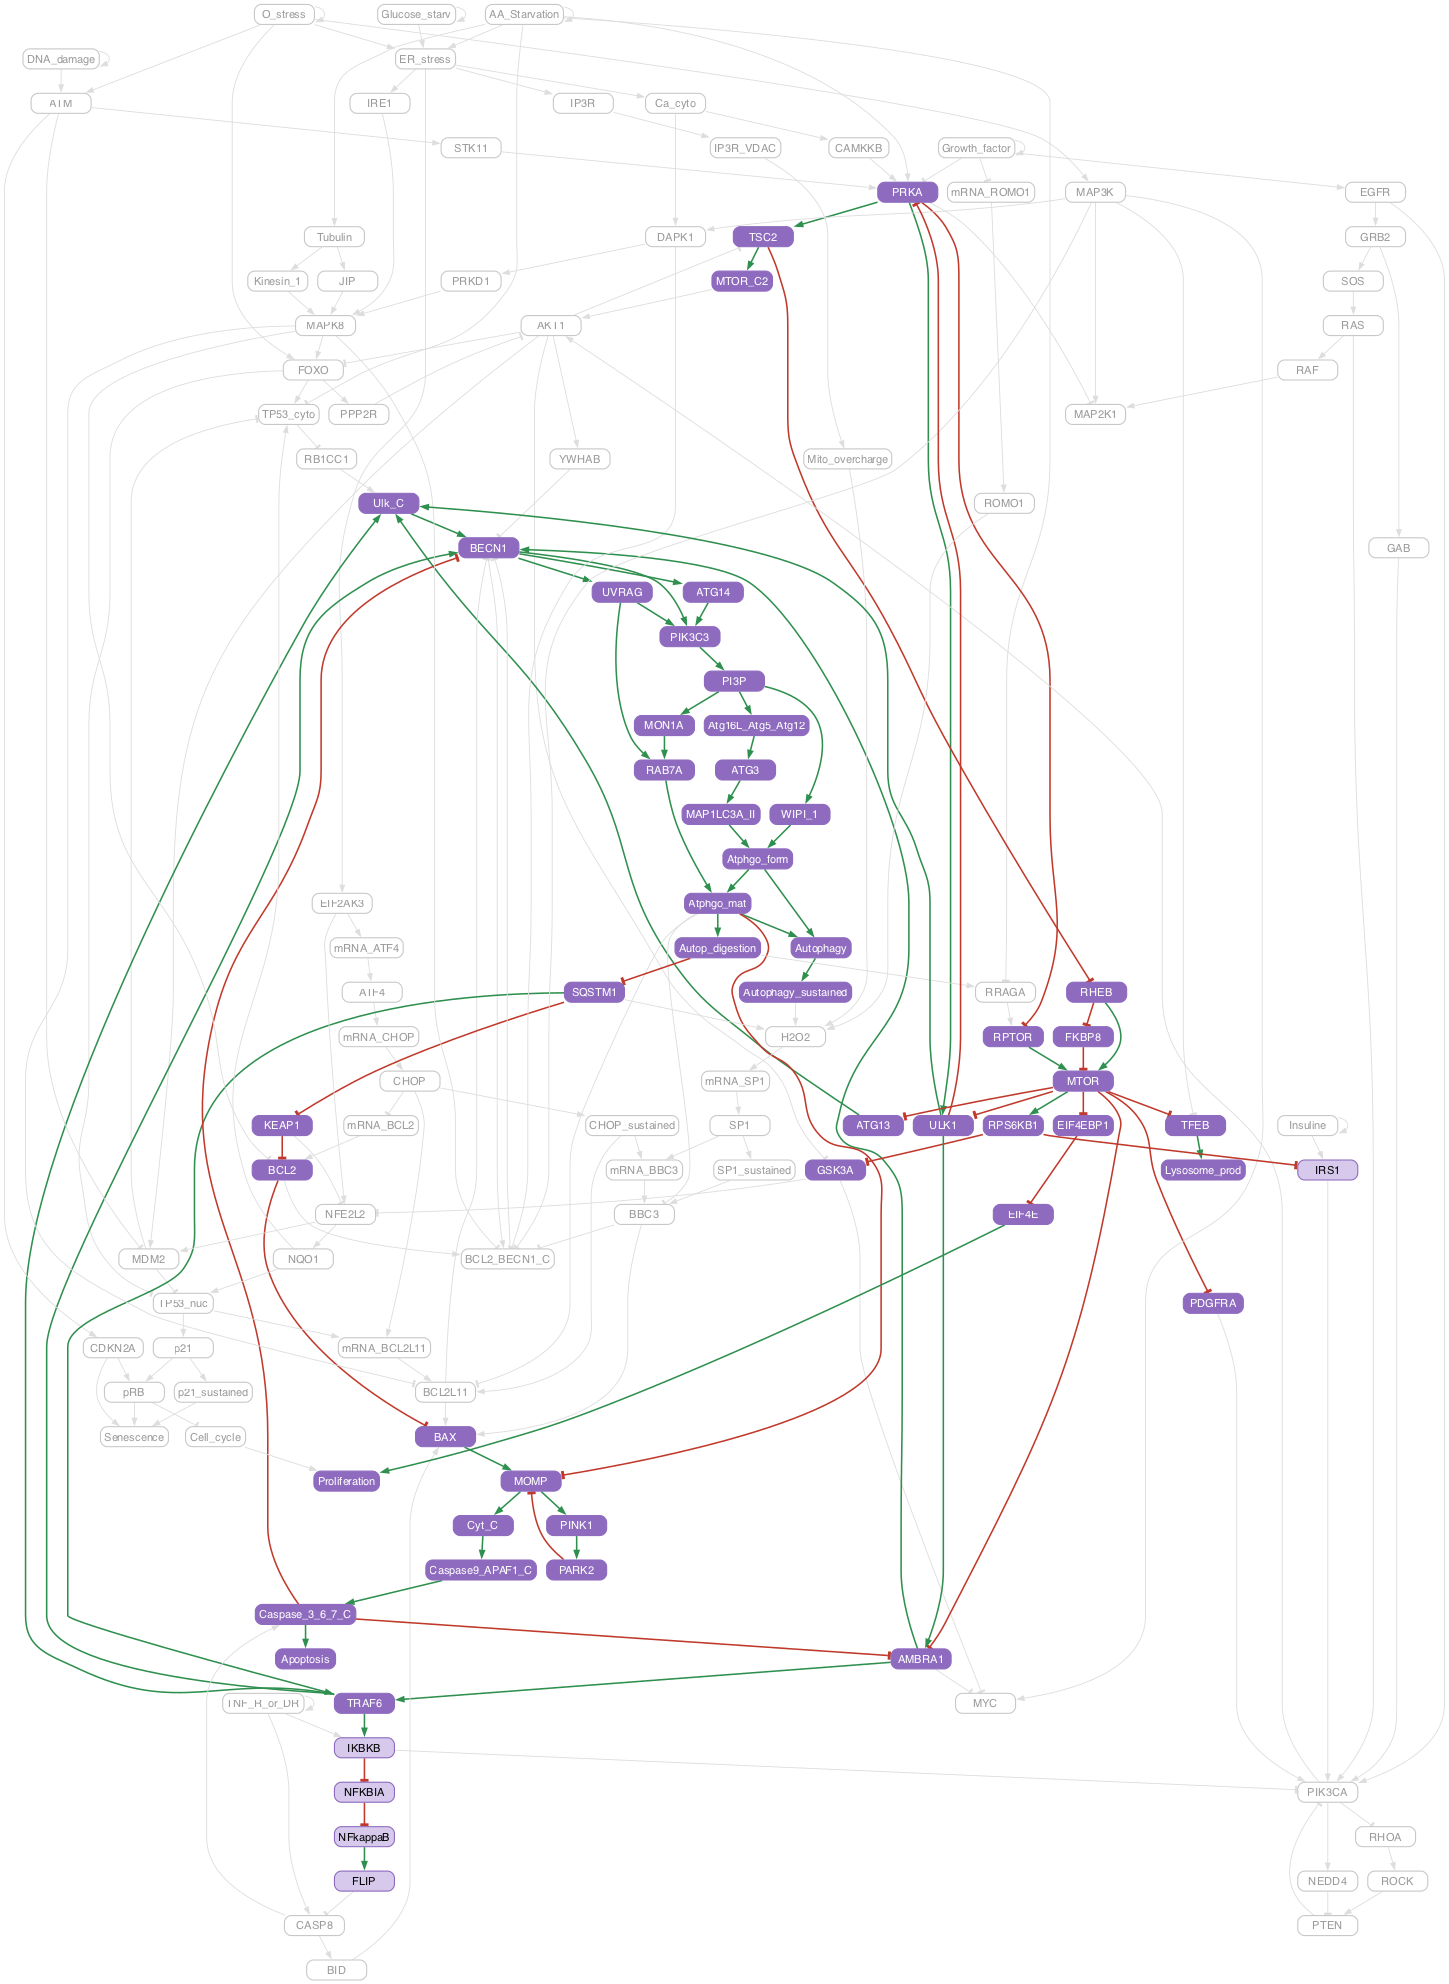

In [8]:
draw_full_network("hierarchical")

In both layouts the cycling nodes form one connected block: the AMPK–MTOR–ULK1 module, the
autophagy cascade, the MAPK8→BCL2⊣BAX→MOMP route to apoptosis and the readouts. The fixed nodes
are the inputs and the modules they hold constant in P5: ER stress/UPR, PI3K/AKT, p53 and the RAS
pathway.

### The cycling subnetwork on its own

The P5.1 cycling subnetwork (49 nodes) with the hierarchical layout, before any SCC analysis.
The other three attractors add at most the five light-purple nodes above.

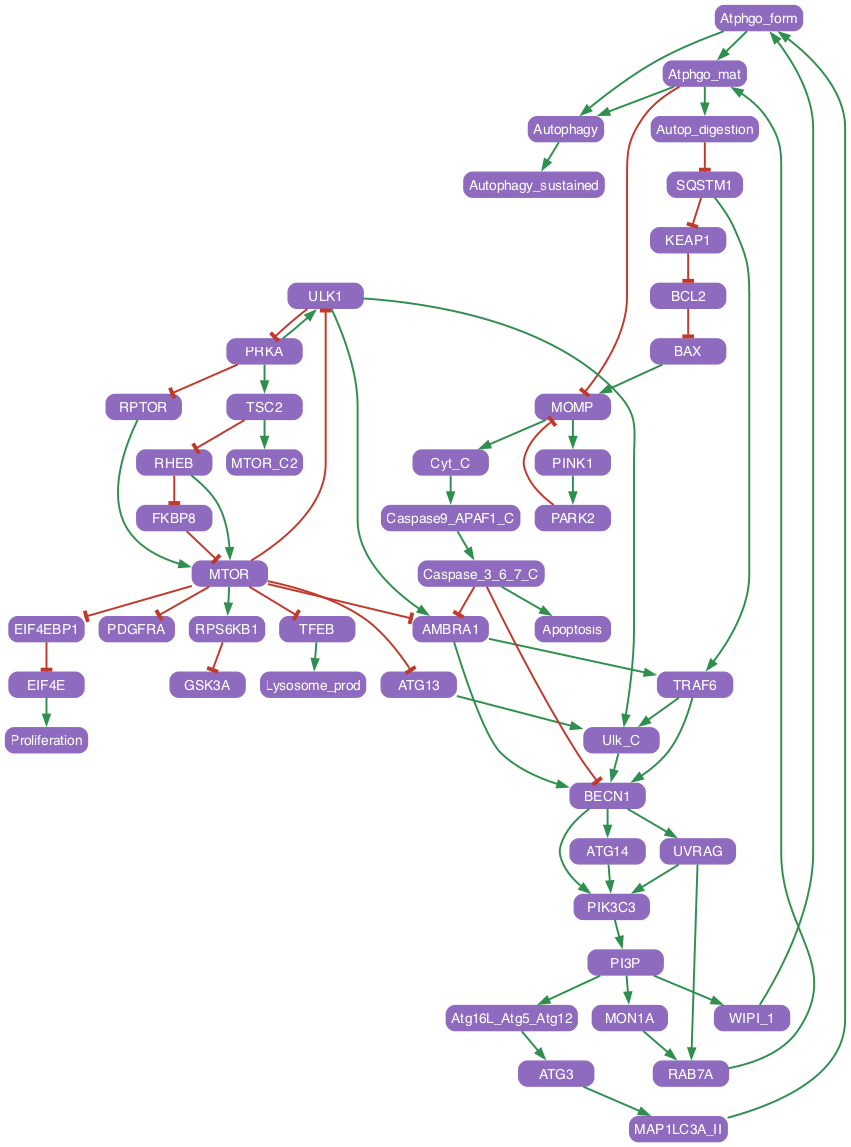

In [9]:
A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.3")
A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                   height="0.25", margin="0.05,0.02", **NODE_STYLE["all"])
for a, b in sub["P5.1"].edges:
    positive = sub["P5.1"][a][b]["sign"] == "+"
    A.add_edge(a, b, color="#2f8f4e" if positive else "#c0392b", penwidth="1.4",
               arrowhead="normal" if positive else "tee", arrowsize="0.7")
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

## 4 — SCCs of the cycling subnetwork

List every non-trivial SCC (more than one node, or a self-loop), its feedback loops, and how many
of them are negative (odd number of inhibitions).

In [10]:
def loop_sign(g, loop):
    return "-" if sum(g[a][b]["sign"] == "-" for a, b in zip(loop, loop[1:] + loop[:1])) % 2 else "+"

def nontrivial_sccs(g):
    return sorted((s for s in nx.strongly_connected_components(g)
                   if len(s) > 1 or g.has_edge(*[next(iter(s))] * 2)), key=len)

def scc_table(g):
    rows = []
    for s in nontrivial_sccs(g):
        loops = list(nx.simple_cycles(g.subgraph(s)))
        rows.append({"nodes": len(s), "loops": len(loops),
                     "negative loops": sum(loop_sign(g, c) == "-" for c in loops),
                     "members": ", ".join(sorted(s))})
    return pd.DataFrame(rows)

pd.concat({k: scc_table(g) for k, g in sub.items()}, names=["attractor", "SCC"])

nodes  loops  negative loops  \
attractor SCC                                 
P5.1      0        7      4               4   
          1       27    101              61   
P5.2      0        7      4               4   
          1       27    101              61   
P5.3      0        7      4               4   
          1       27    101              61   
P5.4      0        7      4               4   
          1       27    101              61   

                                                                                                                                                                                                                                                             members  
attractor SCC                                                                                                                                                                                                                                                         
P5.1      0                                                                                                                                                                                                               FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1    AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1  
P5.2      0                                                                                                                                                                                                               FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1    AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1  
P5.3      0                                                                                                                                                                                                               FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1    AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1  
P5.4      0                                                                                                                                                                                                               FKBP8, MTOR, PRKA, RHEB, RPTOR, TSC2, ULK1  
          1    AMBRA1, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, BAX, BCL2, BECN1, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, KEAP1, MAP1LC3A_II, MOMP, MON1A, PARK2, PI3P, PIK3C3, PINK1, RAB7A, SQSTM1, TRAF6, UVRAG, Ulk_C, WIPI_1

All four attractors give the **same two SCCs**:

* a **7-node SCC whose 4 loops are all negative**: `PRKA, ULK1, MTOR, RPTOR, TSC2, RHEB, FKBP8`;
* a **22-node SCC** of the autophagy and apoptosis cascades, with 33 positive loops and one negative loop.

The remaining cycling nodes, the three readouts included, are on no loop: they are feedforward.

## 5 — Is the 7-node SCC the oscillator?

Two checks on P5.1 (the other three are identical): which loops each SCC holds, and how the SCCs are
connected.

In [11]:
def loop_string(g, loop):
    start = next((h for h in ["PRKA", "MOMP", "BECN1", "PIK3C3"] if h in loop), min(loop))
    i = loop.index(start)
    path = loop[i:] + loop[:i] + [start]
    return path[0] + "".join((" → " if g[a][b]["sign"] == "+" else " ⊣ ") + b
                             for a, b in zip(path, path[1:]))

g = sub["P5.1"]
oscillator, crosstalk = nontrivial_sccs(g)
pd.DataFrame([{"SCC": "7-node" if s is oscillator else "22-node", "length": len(c), "loop": loop_string(g, c)}
              for s in (oscillator, crosstalk) for c in nx.simple_cycles(g.subgraph(s))
              if loop_sign(g, c) == "-"]).sort_values(["SCC", "length"], ignore_index=True)

,SCC,length,loop
0,22-node,3,MOMP → PINK1 → PARK2 ⊣ MOMP
1,22-node,7,BECN1 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1
2,22-node,8,BECN1 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion ⊣ SQSTM1 → TRAF6 → Ulk_C → BECN1
3,22-node,9,BECN1 → PIK3C3 → PI3P → WIPI_1 → Atphgo_form → Atphgo_mat → Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1
4,22-node,9,BECN1 → PIK3C3 → PI3P → MON1A → RAB7A → Atphgo_mat → Autop_digestion ⊣ SQSTM1 → TRAF6 → BECN1
...,...,...,...
60,22-node,21,MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C ⊣ AMBRA1 → TRAF6 → Ulk_C → BECN1 → UVRAG → PIK3C3 → PI3P → Atg16L_Atg5_Atg12 → ATG3 → MAP1LC3A_II → Atphgo_form → Atphgo_mat → Autop_digestion ⊣ SQSTM1 ⊣ KEAP1 ⊣ BCL2 ⊣ BAX → MOMP
61,7-node,2,PRKA → ULK1 ⊣ PRKA
62,7-node,4,PRKA ⊣ RPTOR → MTOR ⊣ ULK1 ⊣ PRKA
63,7-node,5,PRKA → TSC2 ⊣ RHEB → MTOR ⊣ ULK1 ⊣ PRKA


In [12]:
print("edges into the 7-node SCC from other cycling nodes:",
      [(a, b) for a, b in g.in_edges(oscillator) if a not in oscillator])
print("7-node SCC reaches the 22-node SCC:", nx.has_path(g, "PRKA", "BECN1"))
print("readouts downstream of the 7-node SCC:", [r for r in READOUTS if r in nx.descendants(g, "PRKA")])

edges into the 7-node SCC from other cycling nodes: []
7-node SCC reaches the 22-node SCC: True
readouts downstream of the 7-node SCC: ['Proliferation', 'Autop_digestion', 'Apoptosis']


* The 7-node SCC holds the four negative loops through `PRKA` that `00_1` calls the AMPK–ULK1–MTOR
  oscillator: `PRKA → ULK1 ⊣ PRKA` and three longer versions through MTOR.
* No other cycling node regulates it, so it is the **source** of the SCC graph. It drives the
  22-node SCC and all three readouts, and receives nothing back. Its negative loops are the only
  ones that can keep the attractor cycling on their own.
* The 22-node SCC's only negative loop is mitophagy, `MOMP → PINK1 → PARK2 ⊣ MOMP`. It follows the
  oscillator.

So the SCC decomposition of the cycling subnetwork finds the core oscillator **without any loop
classification by hand**.

### Why the cycling subset is needed

In the full interaction graph the same 7 nodes are buried in one 68-node SCC. These are the
edges that enter them from outside, and whether their source cycles in P5.1:

In [13]:
print("SCC of PRKA in the full graph:",
      len(next(s for s in nx.strongly_connected_components(full) if "PRKA" in s)), "nodes")
pd.DataFrame([{"edge": f"{a} {'→' if full[a][b]['sign'] == '+' else '⊣'} {b}",
               "source in P5.1": "cycling" if a in g else f"fixed = {spaces['P5.1'][a]}"}
              for a, b in full.in_edges(oscillator) if a not in oscillator])

SCC of PRKA in the full graph: 73 nodes


,edge,source in P5.1
0,AA_Starvation → PRKA,fixed = 0
1,CAMKKB → PRKA,fixed = 0
2,Growth_factor ⊣ PRKA,fixed = 0
3,STK11 → PRKA,fixed = 0
4,AKT1 ⊣ TSC2,fixed = 0
5,RRAGA → RPTOR,fixed = 1


Every feedback into the oscillator comes from a node that is fixed inside P5 (for example `AKT1 = 0`,
or the inputs). Removing the fixed nodes cuts those edges, and the oscillator becomes an SCC of its own.

Below, the P5.1 cycling subnetwork is coloured by SCC (flat arrowhead = inhibition, square = readout).

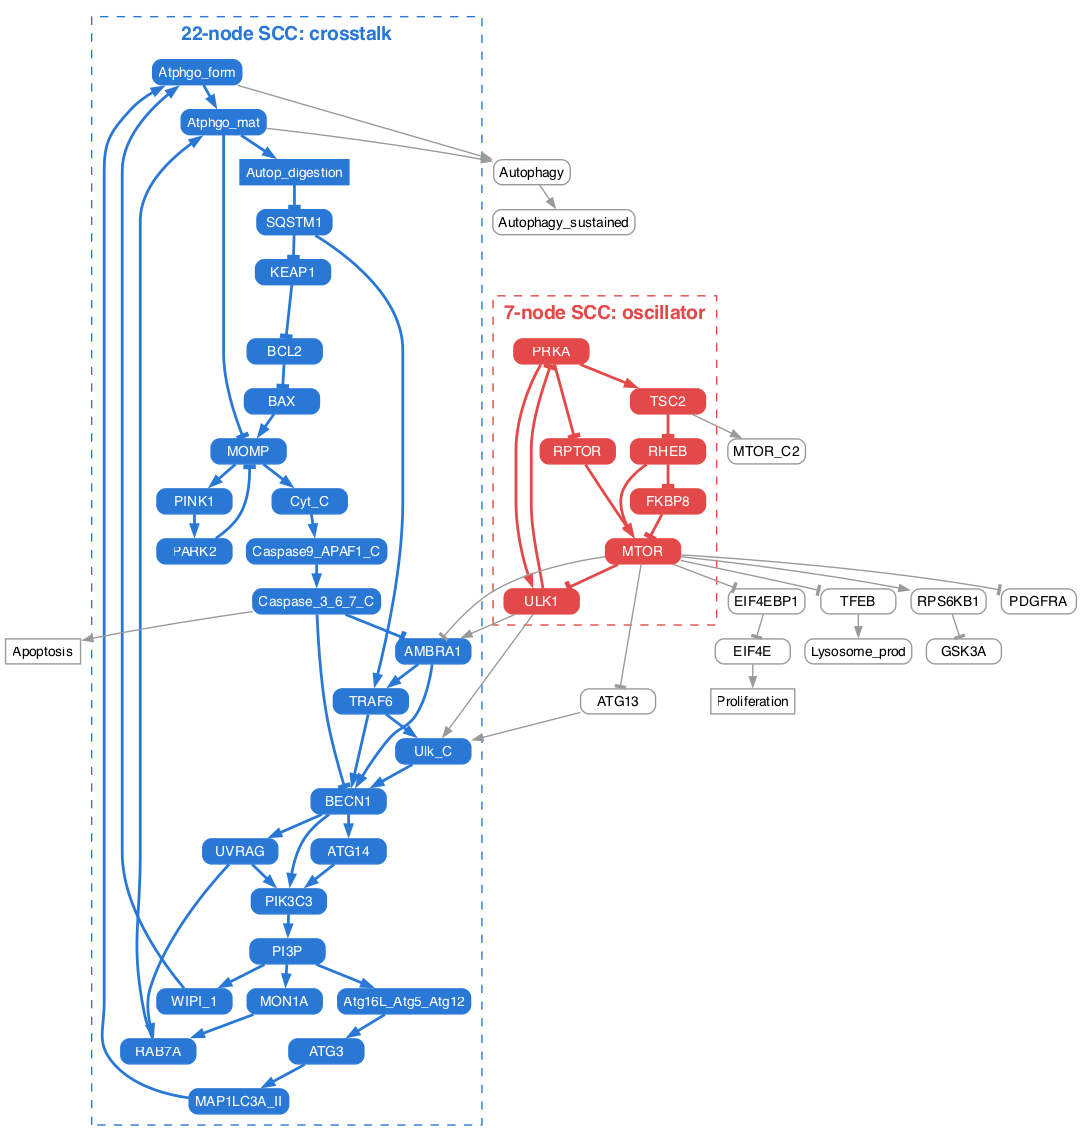

In [14]:
COLOR = {"oscillator": "#e34948", "crosstalk": "#2a78d6", "feedforward": "#9a9a9a"}
group = {v: "oscillator" if v in oscillator else "crosstalk" if v in crosstalk else "feedforward" for v in g}

A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.15", ranksep="0.25")
A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                   height="0.25", margin="0.06,0.02")
for v in g:
    ff = group[v] == "feedforward"
    A.add_node(v, fillcolor="white" if ff else COLOR[group[v]], color=COLOR[group[v]],
               fontcolor="black" if ff else "white", style="filled" if v in READOUTS else "rounded,filled")
for a, b in g.edges:
    same = group[a] == group[b] != "feedforward"
    A.add_edge(a, b, color=COLOR[group[a]] if same else "#9a9a9a", penwidth="2" if same else "1",
               arrowhead="normal" if g[a][b]["sign"] == "+" else "tee", arrowsize="0.7")
for name, label in [("oscillator", "7-node SCC: oscillator"), ("crosstalk", "22-node SCC: crosstalk")]:
    A.add_subgraph([v for v in g if group[v] == name], name=f"cluster_{name}", label=label,
                   style="dashed", color=COLOR[name], fontcolor=COLOR[name], fontname="Helvetica-Bold")
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

## Summary

* In all four P5 attractors, the cycling nodes (49–54) are exactly the free nodes of the trap space.
  Every edge between them is functional inside the attractor.
* The SCC decomposition of the cycling subnetwork is the same in all four attractors: a 7-node SCC
  of purely negative loops and a 22-node crosstalk SCC with one negative loop (mitophagy).
* The 7-node SCC is the AMPK–ULK1–MTOR oscillator of `00_1`. It is the source SCC: no other
  cycling node regulates it, and it drives the crosstalk SCC and all three readouts. A single SCC
  decomposition therefore identifies the core oscillator.
* Restricting to the cycling nodes is essential. In the full graph the oscillator is part of a
  68-node SCC, closed by feedback from nodes that are fixed in P5.